In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [2]:
class RateCalculations:
    def __init__(self, mass_DM, omega_val, q_list, s_factor, cross_section):
        c = 2.998e5 # in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.ref_momentum = mass_DM*self.v_disp  # massless mediator couples to bartyon number 

        # Swapped: single omega, array of q
        self.omega_val = omega_val
        self.q_list = q_list 
        self.s_factor = s_factor
        
        self.cross_section = cross_section # cm^2
        self.v_max = self.v_esc + self.v_earth 
        self.num_density = 2.15e25 # per kg
        
        self.keV2InvS = 2.418e17 # keV to 1/s
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6

    def get_v_min(self, mass_DM, q_arr):
        return self.omega_val / q_arr + q_arr / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) 
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self, v_min): 
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral

    def get_inverse_mean_func(self, mass_DM, q_arr): 
        v_min = self.get_v_min(mass_DM, q_arr)
        return np.where(v_min > (self.v_esc + self.v_earth), 0., 
                        np.where(v_min < (self.v_esc - self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    def get_diff_rate_dRdomega(self):
        reducedMass = self.mass_DM * self.mass_proton / (self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4 * np.pi * self.density_target * self.mass_DM * reducedMass**2)
        # Integrand includes q_list to complete the integration over dq
        integrand = self.q_list * self.get_inverse_mean_func(self.mass_DM, self.q_list) * self.s_factor * (self.ref_momentum / self.q_list)**4
        return constFactor * sp.integrate.simpson(integrand, self.q_list) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg

In [3]:
nSiteData = np.load("nSiteSFactor_lwa_finer.npz")
s_factor_nSite = nSiteData["s_tot"]
s_factor_nSite_incoh = nSiteData["s_diag"]
s_factor_nSite_incoh_lwa = nSiteData["s_lwa"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]

In [4]:
# latticeConst=2*np.pi/2.28
# q_lwa = q_list_nSite[:np.sum(q_list_nSite<1.14)]
# omega_lwa = 2*10e-6*np.sin(q_lwa*latticeConst/2)
# s_lwa = np.zeros((len(q_lwa), len(omega_list_nSite)))
# indices = np.abs(omega_list_nSite[:, None] - omega_lwa).argmin(axis=0)
# s_lwa[np.arange(len(indices)), indices] = 2*np.pi*28**2/(latticeConst**3/4)*q_lwa**2/(2*26161e3*omega_lwa)/(omega_list_nSite[1]-omega_list_nSite[0])
# s_factor_nSite_incoh_lwa = s_factor_nSite_incoh.copy()
# s_factor_nSite_incoh_lwa[:s_lwa.shape[0]] = s_lwa

In [5]:
def get_impulse_approx(q_list, omega, omega_avg=30e-6):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q_list**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega-(q_list**2/(2*mass)))**2 / (2*deltasq)) 

def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [6]:
cross_section = 1e-40 # cm^2
omega_avg = 13.13e-6

dm_length = 200
dmmasslist_4plot = np.array([100, 1e3, 40e3, 100e3, 1e6]) # 10^2 ~ 10^6 keV
omega_threshold = 1e-6 # keV

dRdomega_result_4plot = []
dRdomega_result_incoh_4plot = []

# Constants for Impulse Approximation (IA)
mass_si = 26161e3 # Silicon mass in keV
latticeConst = 2 * np.pi / 2.28 
omega_avg = 13.13e-6 # Average phonon energy from your data
cross_section = 1e-40 
omega_threshold = 1e-6

def calculate_rates_for_masses(dmmasslist, q_list_nSite, omega_list_nSite, s_factor_nSite, s_factor_nSite_incoh):
    """
    Calculates dR/domega for various DM masses, extending the q-range via 
    Impulse Approximation where necessary.
    """
    # Results containers: Shape will be (len(dmmasslist), len(omega_list_nSite))
    dRdomega_result_4plot = []
    dRdomega_result_incoh_4plot = []
    dRdomega_result_incoh_lwa_4plot = []


    # Constants for RateCalculations (Assumed cross section for example)
    sigma_n = 1e-40 # cm^2

    for m_dm in dmmasslist:
        mass_rates_tot = []
        mass_rates_incoh = []
        mass_rates_incoh_lwa = []


        # Get global q limits for this mass to check if extension is needed
        # We use the threshold of the current omega being processed in the loop
        for i, omega in enumerate(omega_list_nSite):
            q_min_lim, q_max_lim = get_q_lim(m_dm, omega_threshold=omega)
            
            current_q_max = np.max(q_list_nSite)
            
            # Check if we need to append more q values
            if q_max_lim > current_q_max:
                # Generate 2000 new points from current max to the required q_max
                q_extra = np.linspace(current_q_max, q_max_lim, 2000)
                q_combined = np.concatenate([q_list_nSite, q_extra])
                
                # Calculate Impulse Approx for the new q range
                s_extra = get_impulse_approx(q_extra, omega)
                
                # Combine original data for this specific omega with the new points
                # s_factor_nSite is (q, omega), so we take the column for current omega
                s_tot_combined = np.concatenate([s_factor_nSite[:, i], s_extra])
                s_incoh_combined = np.concatenate([s_factor_nSite_incoh[:, i], s_extra])
                s_incoh_lwa_combined = np.concatenate([s_factor_nSite_incoh[:, i], s_extra])

            else:
                q_combined = q_list_nSite
                s_tot_combined = s_factor_nSite[:, i]
                s_incoh_combined = s_factor_nSite_incoh[:, i]
                s_incoh_lwa_combined = s_factor_nSite_incoh_lwa[:, i]
            # Initialize the RateCalculations for this specific omega and DM mass
            # Total Rate
            calc_tot = RateCalculations(m_dm, omega, q_combined, s_tot_combined, sigma_n)
            mass_rates_tot.append(calc_tot.get_diff_rate_dRdomega())
            
            # Incoherent Rate
            calc_incoh = RateCalculations(m_dm, omega, q_combined, s_incoh_combined, sigma_n)
            mass_rates_incoh.append(calc_incoh.get_diff_rate_dRdomega())

            calc_incoh_lwa = RateCalculations(m_dm, omega, q_combined, s_incoh_lwa_combined, sigma_n)
            mass_rates_incoh_lwa.append(calc_incoh_lwa.get_diff_rate_dRdomega())
            
        dRdomega_result_4plot.append(mass_rates_tot)
        dRdomega_result_incoh_4plot.append(mass_rates_incoh)
        dRdomega_result_incoh_lwa_4plot.append(mass_rates_incoh_lwa)
    return np.array(dRdomega_result_4plot), np.array(dRdomega_result_incoh_4plot), np.array(dRdomega_result_incoh_lwa_4plot)



In [7]:
# --- Execution ---
dmmasslist_4plot = np.array([1e2,  3e2, 1e3, 10e3, ])

dRdomega_result_4plot, dRdomega_result_incoh_4plot, dRdomega_result_incoh_lwa_4plot = calculate_rates_for_masses(
    dmmasslist_4plot, q_list_nSite, omega_list_nSite, s_factor_nSite, s_factor_nSite_incoh
)
            

In [8]:
def calculate_rates_impulse_only(dmmasslist, omega_list):
    """
    Calculates dR/domega using ONLY the impulse approximation.
    Generates 3000 q values between q_min and q_max for each omega.
    """
    # Results containers
    dRdomega_result_4plot = []
    dRdomega_result_incoh_4plot = []

    # Constants
    sigma_n = 1e-40 # cm^2 (example cross section, adjust as needed)
    v_max = 0.00247 # in c (matching your get_q_lim function)

    for m_dm in dmmasslist:
        mass_rates_tot = []
        mass_rates_incoh = []
        
        for omega in omega_list:
            # Kinematic limit check: 
            # 2 * omega must be <= mass_DM * v_max^2 to be physically possible.
            # This prevents math errors (negative square roots) in get_q_lim.
            if 2 * omega > m_dm * (v_max**2):
                mass_rates_tot.append(0.0)
                mass_rates_incoh.append(0.0)
                continue
            
            # Get q limits for this specific mass and omega
            q_min, q_max = get_q_lim(m_dm, omega_threshold=omega)
            
            # Generate exactly 3000 q values between the allowed limits
            q_list_impulse = np.linspace(q_min, q_max, 3000)
            
            # Calculate structure factor using purely the impulse approximation
            s_factor_impulse = get_impulse_approx(q_list_impulse, omega)
            
            # Initialize RateCalculations and compute the rate
            calc = RateCalculations(m_dm, omega, q_list_impulse, s_factor_impulse, sigma_n)
            rate = calc.get_diff_rate_dRdomega()
            
            # Since total and incoh are identical under pure impulse approx, 
            # we append the same calculated rate to both lists
            mass_rates_tot.append(rate)
            mass_rates_incoh.append(rate)
            
        dRdomega_result_4plot.append(mass_rates_tot)
        dRdomega_result_incoh_4plot.append(mass_rates_incoh)

    return np.array(dRdomega_result_4plot), np.array(dRdomega_result_incoh_4plot)



In [9]:
# --- Execution ---
# Generate the new arrays for plotting
dRdomega_impulse_tot, dRdomega_impulse_incoh = calculate_rates_impulse_only(
    dmmasslist_4plot, omega_list_nSite
)

C:\Users\xylin\AppData\Local\Temp\ipykernel_572\1738809985.py:5: RuntimeWarning: divide by zero encountered in divide
  return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega-(q_list**2/(2*mass)))**2 / (2*deltasq))
C:\Users\xylin\AppData\Local\Temp\ipykernel_572\1738809985.py:5: RuntimeWarning: invalid value encountered in divide
  return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega-(q_list**2/(2*mass)))**2 / (2*deltasq))
C:\Users\xylin\AppData\Local\Temp\ipykernel_572\3128763039.py:29: RuntimeWarning: invalid value encountered in divide
  return self.omega_val / q_arr + q_arr / (2 * mass_DM)
C:\Users\xylin\AppData\Local\Temp\ipykernel_572\3128763039.py:58: RuntimeWarning: divide by zero encountered in divide
  integrand = self.q_list * self.get_inverse_mean_func(self.mass_DM, self.q_list) * self.s_factor * (self.ref_momentum / self.q_list)**4


In [10]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

In [11]:
# def plot_rate_grid(dmmasslist, omega_list, rates_tot, rates_incoh, xmax_list=None):
#     """
#     Creates a subplot grid.
#     Rows correspond to different DM masses.
#     Col 0 is the (incoherent) rate, Col 1 is the total rate.
#     xmax_list: an optional list of maximum x-values for each row.
#     """
#     # sharex=False allows each row to have independent x-axis limits
#     fig, axes = plt.subplots(nrows=len(dmmasslist), ncols=2, figsize=(12, 18), sharex=False, sharey=True)
    
#     for i, m_dm in enumerate(dmmasslist):
#         # --- Column 0: Diagonal (Incoherent) ---
#         ax_diag = axes[i, 0]
#         ax_diag.set_ylim(0,2e6)
#         ax_diag.plot(omega_list*1e6, rates_incoh[i], color='tab:blue', linewidth=2, label="Incoherent")
#         # ax_diag.plot(omega_list*1e6, sp.signal.savgol_filter(rates_incoh[i], 20, 2), color='tab:green', linewidth=1.5)
#         ax_diag.plot(omega_list*1e6, dRdomega_impulse_tot[i], color="lightgray", linestyle="--", label="IA")
        
#         ax_diag.set_title(f'Incoh approx, $m_\chi$ = {m_dm/1000:g} MeV')
#         if i == 0:
#             ax_diag.set_ylim(-.05e6, .6e6)
#             ax_diag.legend()
#         if i == 1:
#             ax_diag.set_ylim(-.2e6, 3e6)
#         ax_diag.set_ylabel('$dR/d\omega$')
        
#         # Apply scientific notation to the y-axis
#         ax_diag.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
        
#         # --- Column 1: Total ---
#         ax_tot = axes[i, 1]
#         ax_tot.plot(omega_list*1e6, rates_tot[i], color='tab:orange', linewidth=2, label="Total")
#         # ax_tot.plot(omega_list*1e6, sp.signal.savgol_filter(rates_tot[i], 20, 2), color='tab:red', linewidth=2)
        
#         ax_tot.set_title(f'Total, $m_\chi$ = {m_dm/1000:g} MeV')
#         ax_tot.plot(omega_list*1e6, dRdomega_impulse_tot[i], color="lightgray", linestyle="--", label="IA")
#         if i == 0:
#             ax_tot.set_ylim(-.05e6, .6e6)
#             ax_tot.legend()
#         if i == 1:
#             ax_tot.set_ylim(-.2e6, 3e6)

#         # Apply scientific notation to the y-axis
#         ax_tot.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

#         # --- X-Axis Customization ---
#         # Apply the custom x-maximums if provided, otherwise default to 200
#         if xmax_list is not None:
#             ax_diag.set_xlim(0, xmax_list[i])
#             ax_tot.set_xlim(0, xmax_list[i])
#         else:
#             ax_diag.set_xlim(0, 200)
#             ax_tot.set_xlim(0, 200)

#         # Labels on all rows since x-axes are no longer shared
#         ax_diag.set_xlabel('$\omega$ [meV]')
#         ax_tot.set_xlabel('$\omega$ [meV]')

#     # Automatically adjust subplot parameters to give specified padding
#     plt.tight_layout()
#     plt.show()

# # --- Implementation ---
# # Define your desired maximum x-values for each row (must match the length of dmmasslist_4plot)
# my_xmax_list = [50, 50, 50, 50, 50] # Example values

# # Pass your previously calculated arrays into the new plotting function
# plot_rate_grid(dmmasslist_4plot, omega_list_nSite, dRdomega_result_4plot, dRdomega_result_incoh_lwa_4plot, xmax_list=my_xmax_list)

In [12]:
# def plot_rate_grid_3x4(dmmasslist, omega_list, rates_tot, rates_incoh, rates_incoh_lwa, dRdomega_impulse_tot, xmax_list=None, ylim_list=None):
#     """
#     Creates a 3x4 subplot grid for 4 DM masses.
#     ylim_list: Optional list of (ymin, ymax) tuples for each column (DM mass).
#     """
#     fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 10), sharex=False)
    
#     row_data = [rates_tot, rates_incoh, rates_incoh_lwa]
#     row_labels = ["Full structure factor", "Incoherent approximation", "Inc + LW approx"]
#     row_colors = ['tab:blue', 'tab:orange', 'tab:green']
    
#     for row_idx in range(3):
#         for col_idx in range(4):
#             ax = axes[row_idx, col_idx]
#             m_dm = dmmasslist[col_idx]
            
#             # Plot the lines
#             ax.plot(omega_list*1e6, row_data[row_idx][col_idx], color=row_colors[row_idx], linewidth=2)
#             ax.plot(omega_list*1e6, dRdomega_impulse_tot[col_idx], color="lightgray", linestyle="--")
            
#             # --- Formatting ---
#             if row_idx == 0:
#                 ax.set_title(f'$m_\\chi$ = {m_dm/1000:g} MeV', fontsize=24, )
            
#             if col_idx == 0:
#                 if row_idx == 0:
#                     ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')
#                 if row_idx == 1:
#                     ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')
#                 if row_idx == 2:
#                     ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')



#             # --- Row Titles ---
#             # Apply the row title to the right side of the last column
#             if col_idx == 3:
#                 ax.yaxis.set_label_position("right")

#             if row_idx == 2:
#                 ax.set_xlabel('$\\omega$ [meV]')
#             else:
#                 # Remove the x-axis numbers for the top and middle rows
#                 ax.tick_params(labelbottom=False)    
            
#             ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
            
#             # --- X-Axis and Y-Axis Customization ---
            
#             # Apply X limits
#             if xmax_list is not None and len(xmax_list) == 4:
#                 ax.set_xlim(0, xmax_list[col_idx])
#             else:
#                 ax.set_xlim(0, 200)

#             # Apply Y limits manually per column (mass)
#             if ylim_list is not None and len(ylim_list) == 4:
#                 ax.set_ylim(ylim_list[col_idx][0], ylim_list[col_idx][1])

#     # --- Manual Spacing Control ---
#     # Adjusted 'right' from 0.98 to 0.94 so the right-side row titles fit perfectly
#     fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.08, wspace=0.15, hspace=0.15)
#     axes[0,0].text(7,6.8e5,'Full Structure Factor',fontsize=22, color="tab:blue")
#     axes[1,0].text(11,5.8e5,'       Incoherent\nApproximation',fontsize=22, color="tab:orange")
#     axes[2,0].text(11,5.8e5,'         Inc + LW\nApproximation',fontsize=22, color="tab:green")
#     plt.suptitle("Massless Scalar Mediator", fontsize=26,y=1)


#     plt.show()

# # --- Implementation ---

# my_xmax_list = [25, 25, 50, 100] 

# # Define your custom y-limits for each of the 4 columns as (ymin, ymax) tuples
# # (Adjust these specific numbers to match your data)
# my_ylim_list = [
#     (-0.05e6, 0.8e6),  # Column 0 limits
#     (-0.05e6, 0.8e6),   # Column 1 limits
#     (-0.12e6, 2.0e6),   # Column 2 limits
#     (-1.0e6, 10.0e6)   # Column 3 limits
# ]

# plot_rate_grid_3x4(
#     dmmasslist=dmmasslist_4plot, 
#     omega_list=omega_list_nSite, 
#     rates_tot=dRdomega_result_4plot, 
#     rates_incoh=dRdomega_result_incoh_4plot,
#     rates_incoh_lwa=dRdomega_result_incoh_lwa_4plot, 
#     dRdomega_impulse_tot=dRdomega_impulse_tot, 
#     xmax_list=my_xmax_list,
#     ylim_list=my_ylim_list     # Pass the new y-limits here
# )

# Calculate the first order structure factor (numeric)

In [13]:
C_KM_S = 2.998e5
V_ESC = 500 / C_KM_S
V_EARTH = 240 / C_KM_S
V_DISP = 220 / C_KM_S

def _get_shared_params():
    """Calculates normalization factors used in both solutions."""
    ratio = V_ESC / V_DISP
    norm_fac = (V_DISP**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2 * ratio * np.exp(-ratio**2))
    return ratio, norm_fac

def inverse_mean_sol1(v_min):
    ratio, norm_fac = _get_shared_params()
    
    vel_integral = (np.sqrt(np.pi) * V_DISP * (sp.special.erf((v_min + V_EARTH) / V_DISP) 
                                               - sp.special.erf((v_min - V_EARTH) / V_DISP))
                    - 4 * V_EARTH * np.exp(-ratio**2))   
    
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vel_integral 

def inverse_mean_sol2(v_min): 
    ratio, norm_fac = _get_shared_params()
    
    vel_integral = (np.sqrt(np.pi) * V_DISP * (sp.special.erf(ratio) 
                                               - sp.special.erf((v_min - V_EARTH) / V_DISP))
                    - 2 * (V_ESC - v_min + V_EARTH) * np.exp(-ratio**2))   
    
    return V_DISP**2 * np.pi / (2 * V_EARTH * norm_fac) * vel_integral

def get_inverse_mean_func(v_min): 
    """
    Stand-alone calculation for the DM velocity integral.
    Accepts v_min as a float or numpy array.
    """
    # Logic gates based on Earth's velocity and Galactic escape velocity
    cond_zero = v_min > (V_ESC + V_EARTH)
    cond_sol1 = v_min < (V_ESC - V_EARTH)
    
    return np.where(cond_zero, 0., 
                    np.where(cond_sol1,
                             inverse_mean_sol1(v_min),
                             inverse_mean_sol2(v_min)))

def get_const_factor_value(mass_DM, cross_section=1e-40):
    # Constants from your code
    m_p = 938.272e3        # keV
    rho_DM = 0.3e6         # keV/cm^3
    rho_T = 1.307e30       # keV/cm^3
    
    # Unit conversions
    keV2InvS = 2.418e17
    year2sec = 86400. * 365.
    keV2InvYr = keV2InvS * year2sec
    keV2kg = 1.78e-33
    keV2InvCm = 8.065e6
    
    conversion_combined = (keV2InvCm**2 * keV2InvYr) / keV2kg
    
    reduced_mass_inv_sq = ((mass_DM + m_p)**2) / (mass_DM**2 * m_p**2)
    
    static_prefactor = (rho_DM * cross_section ) / (4 * np.pi * rho_T)
    
    return (static_prefactor / mass_DM) * reduced_mass_inv_sq * conversion_combined


def get_DebyeWallerConst(q_value, nLattice=100, mass=26161e3, omegaNaught=10e-6, energyThreshold=1e-6):
    """
    Calculates the Debye-Waller constant W(q) for a given momentum transfer q.
    
    Parameters:
    - q_value: Momentum transfer (keV^-1)
    - nLattice: Number of lattice points (default: 100)
    - mass: Mass of the nucleus in keV (default: 26161e3 for Silicon)
    - omegaNaught: Base frequency in keV (default: 10e-6)
    - energyThreshold: Minimum energy filter in keV (default: 1e-6)
    
    Returns:
    - W(q): The Debye-Waller constant (dimensionless)
    """
    # 1. Generate the frequencies for the given number of lattice points
    nu = np.arange(1, nLattice)
    omegaList = 2 * omegaNaught * np.sin(np.pi * nu / nLattice)
    
    # 2. Filter out frequencies below the energy threshold
    omegaList = omegaList[omegaList >= energyThreshold]
    
    # 3. Compute W(q)
    sum_inv_omega = np.sum(1 / omegaList)
    W_q = (q_value**2) / (4 * mass * nLattice) * sum_inv_omega
    
    return W_q

# mchi =  3e2
# omglst = np.linspace(0, 19.99, 600) *1e-6 # keV
# qlist = 2/2.756*np.arcsin(omglst/(20*1e-6))
# vmin = omglst/qlist + qlist/(2*mchi)
# dwfactor = get_DebyeWallerConst(qlist)
# drdomg = qlist* get_inverse_mean_func(vmin) * qlist**2/(2*26161e3*omglst)*2*np.pi*28**2/((2.756**3)/4) * get_const_factor_value(mchi)*2/2.756/np.sqrt((20e-6)**2-omglst**2) * np.exp(-2*dwfactor)
# plt.plot(omglst*1e6, drdomg, label="Analytic")
# # plt.plot(omega_list_nSite*1e6, dRdomega_result_incoh_lwa_4plot[0],label="Numeric")
# # plt.xlim(0,20)
# plt.legend()
# plt.title(f"$dR/d\omega$, $m_\chi$ = {mchi/1e3} MeV")
# plt.xlabel('$\omega$ [meV]')
# plt.ylabel("$dR/d\omega$ [kg-yr-keV]$^{-1}$")

In [14]:
def get_const_factor_value(mass_DM, cross_section=1e-40):
    # Constants from your code
    m_p = 938.272e3        # keV
    rho_DM = 0.3e6         # keV/cm^3
    rho_T = 1.307e30       # keV/cm^3
    
    # Unit conversions
    keV2InvS = 2.418e17
    year2sec = 86400. * 365.
    keV2InvYr = keV2InvS * year2sec
    keV2kg = 1.78e-33
    keV2InvCm = 8.065e6
    
    conversion_combined = (keV2InvCm**2 * keV2InvYr) / keV2kg
    
    # Physics scaling
    # mu = (m_DM * m_p) / (m_DM + m_p)
    # Factor = 1 / (m_DM * mu^2) = (m_DM + m_p)^2 / (m_DM^3 * m_p^2)
    
    reduced_mass_inv_sq = ((mass_DM + m_p)**2) / (mass_DM**2 * m_p**2)
    
    static_prefactor = (rho_DM * cross_section * conversion_combined) / (4 * np.pi * rho_T)
    
    return (static_prefactor / mass_DM) * reduced_mass_inv_sq

In [15]:
import sys
sys.path.append(r"C:/Users/xylin/Documents/Researches/multiphonon-direct-detection/StructureFactor1D.py")
from StructureFactor1D import StructureFactor1D

In [16]:
def calc_first_order_s_factor(q_value, omegalength, nLattice, max_omega): 
    # Initialize the calculator
    sFacCalc = StructureFactor1D(nLattice=nLattice, q_value=q_value, couplingConst=28)
    xlist, delta_omega = np.linspace(0, max_omega, omegalength, retstep=True) 
    
    # Setup and compute first order (init_recursion computes the 1st order)
    sFacCalc.setup_DoS(max_omega, nBins=1000)
    sFacCalc.init_recursion(print_message=False)
    
    # Fetch the 1st-order binned data
    s_diag = sFacCalc.get_binned_s_diag(xlist, delta_omega)
    s_offdiag = sFacCalc.get_binned_s_offdiag(xlist, delta_omega)
    
    # Calculate Long-Wavelength Approximation (LWA)
    if q_value < 1.14:
        s_tot_lwa = np.zeros(xlist.shape)
        omega_lwa = 2*10e-6*np.sin(q_value*sFacCalc.latticeConst/2)
        ind = np.abs(xlist - omega_lwa).argmin()
        
        # Add the peak at the appropriate index
        s_tot_lwa[ind] = 2*np.pi*28**2 / (sFacCalc.latticeConst**3 / 4) * q_value**2 / (2*26161e3*omega_lwa) / delta_omega
    else:
        s_tot_lwa = s_diag.copy()
        
    # The total structure factor for 1st order is just the sum of diagonal and off-diagonal
    s_tot = s_diag + s_offdiag
    s_diag_tot = s_diag.copy()
    
    return s_diag_tot, s_tot, s_tot_lwa

omegalength = len(omega_list_nSite)
max_omega = 250 * 1e-6
nLattice = 100

# --- Grid Generation ---
omegalist = np.linspace(0, max_omega, omegalength) 
qscale = np.sqrt(2 * 26161e3 * 13.13e-6) 
qlenth = len(omega_list_nSite)
qlist = np.geomspace(0.001, 2 * qscale, qlenth)

# --- Initialize lists to store results ---
res_diag = []
res_tot = []
res_lwa = []

# --- Simple Sequential Loop Execution ---
for idx, q in enumerate(qlist):
    # Optional progress tracker (since 1000 iterations might take a moment)
    if idx % 100 == 0:
        print(f"Processing q-point {idx}/{qlenth}...")
        
    # Call the 1st-order function
    s_diag_tot, s_tot, s_tot_lwa = calc_first_order_s_factor(
        q_value=q, 
        omegalength=omegalength, 
        nLattice=nLattice, 
        max_omega=max_omega
    )
    
    # Append the 1D arrays to our results lists
    res_diag.append(s_diag_tot)
    res_tot.append(s_tot)
    res_lwa.append(s_tot_lwa)
    
# --- Data Aggregation ---
# Convert lists to 2D numpy arrays. Shape: (qlenth, omegalength)
finalresdiag_1st = np.array(res_diag)
finalres_1st = np.array(res_tot)

s_factor_nSite_2nd = s_factor_nSite - finalres_1st
s_factor_nSite_incoh_2nd = s_factor_nSite_incoh - finalresdiag_1st

Processing q-point 0/2000...
Processing q-point 100/2000...
Processing q-point 200/2000...
Processing q-point 300/2000...
Processing q-point 400/2000...
Processing q-point 500/2000...
Processing q-point 600/2000...
Processing q-point 700/2000...
Processing q-point 800/2000...
Processing q-point 900/2000...
Processing q-point 1000/2000...
Processing q-point 1100/2000...
Processing q-point 1200/2000...
Processing q-point 1300/2000...
Processing q-point 1400/2000...
Processing q-point 1500/2000...
Processing q-point 1600/2000...
Processing q-point 1700/2000...
Processing q-point 1800/2000...
Processing q-point 1900/2000...


In [17]:
dRdomega_result_2nd_4plot, dRdomega_result_incoh_2nd_4plot, dRdomega_result_incoh_lwa_2nd_4plot = calculate_rates_for_masses(
    dmmasslist_4plot, q_list_nSite, omega_list_nSite, s_factor_nSite_2nd, s_factor_nSite_incoh_2nd
)
           

In [18]:
from scipy.stats import binned_statistic

def bin_arrays(x_data, y_data, num_bins=50):
    """
    Coarse-grains 1D data by dividing it into bins and calculating the mean 
    of the y-values within each bin.

    Parameters:
    
    - x_data (array-like): The independent variable array (e.g., omega).
    - y_data (array-like): The dependent variable array (e.g., rate).
    - num_bins (int or sequence): The number of bins to use, or an array of 
                                  specific bin edges.

    Returns:
    - binned_x (ndarray): A 1D array of the center x-values for each bin.
    - binned_y (ndarray): A 1D array of the mean y-values for each bin.
    """
    # Ensure inputs are numpy arrays
    x_data = np.asarray(x_data)
    y_data = np.asarray(y_data)
    
    # Perform the binning
    binned_y, bin_edges, _ = binned_statistic(
        x_data, 
        y_data, 
        statistic='mean', 
        bins=num_bins
    )
    
    # Calculate the center of each bin for the new x-axis
    binned_x = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    return binned_x, binned_y

In [19]:
def calculate_integrand(q_2d, omg_1d, mchi):
    # Reshape omega to be a column vector (600, 1) so it broadcasts correctly 
    # against the (600, N_roots) q_2d array.
    omg_2d = omg_1d[:, np.newaxis]
    v_disp = 220/2.998e5
    ref_momentum = mchi*v_disp 
    # Calculate vmin for every single valid root
    vmin = omg_2d / q_2d + q_2d / (2 * mchi)
    
    # Calculate the physics integrand (WITHOUT the DOS factor at the end)
    # Note: Ensure get_inverse_mean_func can handle arrays containing np.nan!
    inv_mean_val = get_inverse_mean_func(vmin)
    const_val = get_const_factor_value(mchi)
    dwfactor = get_DebyeWallerConst(q_2d)

    term1 = q_2d * inv_mean_val * q_2d**2
    term2 = (2 * 26161e3 * omg_2d)
    constants = 2 * np.pi * 28**2 / ((a**3) / 4) * const_val *  np.exp(-2*dwfactor)
    
    return (term1 / term2) * constants * (ref_momentum / q_2d)**4

         
a = 2.756

def calculate_rate_vs_mass(omega_list_nSite, dmmasslist_4plot, a=2.756, omega_max=20e-6, n_max=50):
    """
    Calculates the differential rate for a list of DM masses, 
    ensuring rates are 0 for omega outside [0, omega_max].
    """
    num_omg = len(omega_list_nSite)
    num_mass = len(dmmasslist_4plot)
    
    # Initialize the output array with zeros
    results = np.zeros((num_mass, num_omg))
    
    # Create a mask for valid physical energy ranges
    # This prevents non-zero results for omega < 0 or omega > omega_max
    valid_mask = (omega_list_nSite > 1e-6) & (omega_list_nSite < omega_max)
    
    # We only perform calculations on the subset of omegas that are valid
    omg_valid = omega_list_nSite[valid_mask]
    
    if len(omg_valid) == 0:
        return results # Return all zeros if no omegas are in range

    # --- 1. Precompute Q-Roots (Only for valid omegas) ---
    q_0 = (2 / a) * np.arcsin(omg_valid / omega_max)
    n_values = np.arange(-n_max, n_max + 1)
    shifts = n_values * (2 * np.pi / a)

    q1_branch = q_0[:, np.newaxis] + shifts[np.newaxis, :]
    q2_branch = -q_0[:, np.newaxis] + shifts[np.newaxis, :]
    all_q_roots = np.concatenate((q1_branch, q2_branch), axis=1)
    
    q_roots = np.where(all_q_roots > 0, all_q_roots, np.nan)
    
    # --- 2. Precompute Density of States ---
    # Since we masked omg_valid to be < omega_max, we avoid the sqrt(0) singularity
    dos_inverse = (2 / a) / np.sqrt(omega_max**2 - omg_valid**2)
    
    # --- 3. Loop over DM Masses ---
    for i, mchi in enumerate(dmmasslist_4plot):
        # Calculate integrand for valid subset
        f_evaluated = calculate_integrand(q_roots, omg_valid, mchi)
        
        # Sum across the roots
        summed_f = np.nansum(f_evaluated, axis=1)
        
        # Apply DOS
        drdomg_valid = summed_f * dos_inverse
        
        # Place the calculated values back into the results array at valid indices
        results[i, valid_mask] = np.nan_to_num(drdomg_valid, nan=0.0, posinf=0.0, neginf=0.0)
        
    return results

drdomg_2d_array = calculate_rate_vs_mass(omega_list_nSite, dmmasslist_4plot)

Text(0, 0.5, '$dR/d\\omega$ [kg-yr-keV]$^{-1}$')

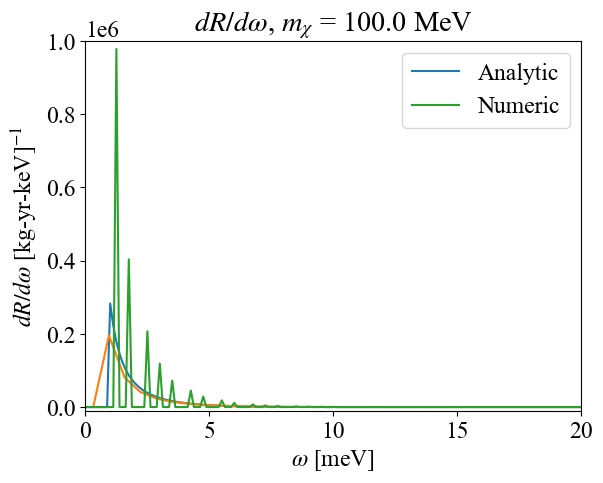

In [20]:
plt.plot(omega_list_nSite*1e6, drdomg_2d_array[0], label="Analytic")
binned_omega, binned_rate = bin_arrays(omega_list_nSite, dRdomega_result_4plot[0], 395)
plt.plot(binned_omega*1e6, binned_rate)
plt.plot(omega_list_nSite*1e6, dRdomega_result_4plot[0],label="Numeric")
plt.xlim(0,20)
plt.ylim(-1e4,1e6)
plt.legend()
plt.title(f"$dR/d\omega$, $m_\chi$ = {dmmasslist_4plot[0]} MeV")
plt.xlabel('$\omega$ [meV]')
plt.ylabel("$dR/d\omega$ [kg-yr-keV]$^{-1}$")

In [21]:
binned_omega_00, binned_rate_00 = bin_arrays(omega_list_nSite, dRdomega_result_4plot[0], 395)
binned_omega_01, binned_rate_01 = bin_arrays(omega_list_nSite, dRdomega_result_4plot[1], 200)
binned_omega_10, binned_rate_10 = bin_arrays(omega_list_nSite, dRdomega_result_incoh_4plot[0], 395)
binned_omega_11, binned_rate_11 = bin_arrays(omega_list_nSite, dRdomega_result_incoh_4plot[1], 200)


0 0
0 1
0 2 binned
0 3 binned
1 0
1 1
1 2 binned
1 3 binned
2 0
2 1
2 2
2 3 binned


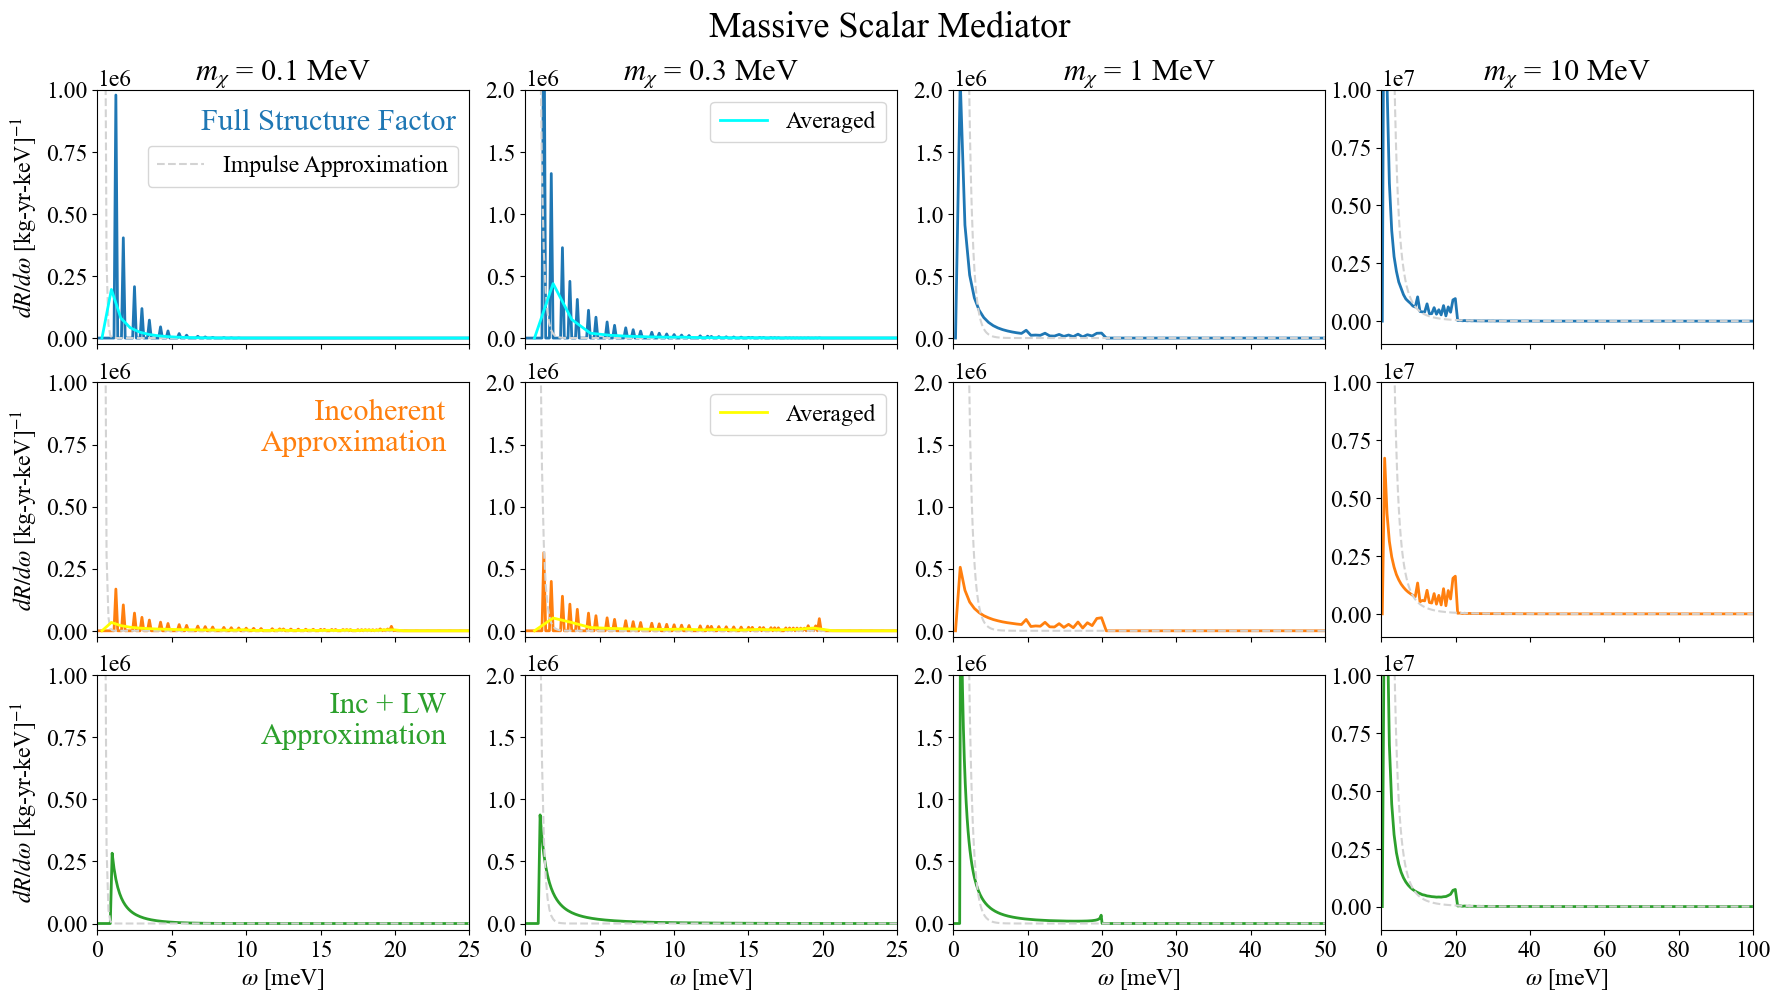

In [28]:
def plot_rate_grid_3x4(dmmasslist, omega_list, rates_tot, rates_incoh, rates_incoh_lwa, dRdomega_impulse_tot, xmax_list=None, ylim_list=None):
    """
    Creates a 3x4 subplot grid for 4 DM masses.
    ylim_list: Optional list of (ymin, ymax) tuples for each column (DM mass).
    """
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 10), sharex=False)
    
    row_data = [rates_tot, rates_incoh, rates_incoh_lwa]
    row_labels = ["Full structure factor", "Incoherent approximation", "Inc + LW approx"]
    row_colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for row_idx in range(3):
        for col_idx in range(4):
            ax = axes[row_idx, col_idx]
            m_dm = dmmasslist[col_idx]

            if col_idx == 2:
                if (row_idx == 0) or (row_idx == 1):
                    print(row_idx,col_idx, "binned")
                    binned_omega, binned_rate = bin_arrays(omega_list, row_data[row_idx][col_idx],395)
                    ax.plot(binned_omega*1e6, binned_rate, color=row_colors[row_idx], linewidth=2)
                else: 
                    print(row_idx,col_idx)
                    ax.plot(omega_list*1e6, row_data[row_idx][col_idx], color=row_colors[row_idx], linewidth=2)
            elif col_idx == 3:                     
                    print(row_idx,col_idx,"binned")
                    binned_omega, binned_rate = bin_arrays(omega_list, row_data[row_idx][col_idx],395)
                    ax.plot(binned_omega*1e6, binned_rate, color=row_colors[row_idx], linewidth=2)
            else:                
                print(row_idx,col_idx)
                ax.plot(omega_list*1e6, row_data[row_idx][col_idx], color=row_colors[row_idx], linewidth=2)
            if col_idx==0 and row_idx==0: 
                ax.plot(omega_list*1e6, dRdomega_impulse_tot[col_idx], color="lightgray", linestyle="--", label='Impulse Approximation')
            else:
                ax.plot(omega_list*1e6, dRdomega_impulse_tot[col_idx], color="lightgray", linestyle="--", )
            
            # --- Formatting ---
            if row_idx == 0:
                ax.set_title(rf'$m_\chi$ = {m_dm/1000:g} MeV', fontsize=22, )
            
            if col_idx == 0:
                if row_idx == 0:
                    ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')
                if row_idx == 1:
                    ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')
                if row_idx == 2:
                    ax.set_ylabel('$dR/d\\omega$ [kg-yr-keV]$^{-1}$')



            # --- Row Titles ---
            # Apply the row title to the right side of the last column
            if col_idx == 3:
                ax.yaxis.set_label_position("right")

            if row_idx == 2:
                ax.set_xlabel('$\\omega$ [meV]')
            else:
                # Remove the x-axis numbers for the top and middle rows
                ax.tick_params(labelbottom=False)    
            
            ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
            
            # --- X-Axis and Y-Axis Customization ---
            
            # Apply X limits
            if xmax_list is not None and len(xmax_list) == 4:
                ax.set_xlim(0, xmax_list[col_idx])
            else:
                ax.set_xlim(0, 200)

            # Apply Y limits manually per column (mass)
            if ylim_list is not None and len(ylim_list) == 4:
                ax.set_ylim(ylim_list[col_idx][0], ylim_list[col_idx][1])
    axes[0,0].plot(binned_omega_00*1e6, binned_rate_00, color='cyan',lw=2)
    axes[0,1].plot(binned_omega_01*1e6, binned_rate_01, color='cyan',lw=2,label="Averaged")
    axes[1,0].plot(binned_omega_10*1e6, binned_rate_10, color='yellow',lw=2)
    axes[1,1].plot(binned_omega_11*1e6, binned_rate_11, color='yellow',lw=2,label="Averaged")
    axes[0,1].legend()
    axes[1,1].legend()
    axes[0,0].legend(loc="center right", bbox_to_anchor=(1, 0.7))
    # --- Manual Spacing Control ---
    # Adjusted 'right' from 0.98 to 0.94 so the right-side row titles fit perfectly
    fig.subplots_adjust(left=0.06, right=0.98, top=0.92, bottom=0.08, wspace=0.15, hspace=0.15)
    axes[0,0].text(7,8.4e5,'Full Structure Factor',fontsize=22, color="tab:blue")
    axes[1,0].text(11,7.25e5,'       Incoherent\nApproximation',fontsize=22, color="tab:orange")
    axes[2,0].text(11,7.25e5,'         Inc + LW\nApproximation',fontsize=22, color="tab:green")
    plt.suptitle("Massive Scalar Mediator", fontsize=26,y=1)

    plt.show()

# --- Implementation ---

my_xmax_list = [25, 25, 50, 100] 

# Define your custom y-limits for each of the 4 columns as (ymin, ymax) tuples
# (Adjust these specific numbers to match your data)
my_ylim_list = [
    (-0.025e6, 1e6),  # Column 0 limits
    (-0.05e6, 2e6),   # Column 1 limits
    (-0.05e6, 2.0e6),   # Column 2 limits
    (-1.0e6, 10.0e6)   # Column 3 limits
]

plot_rate_grid_3x4(
    dmmasslist=dmmasslist_4plot, 
    omega_list=omega_list_nSite, 
    rates_tot=dRdomega_result_4plot, 
    rates_incoh=dRdomega_result_incoh_4plot,
    rates_incoh_lwa=dRdomega_result_incoh_2nd_4plot+drdomg_2d_array, 
    dRdomega_impulse_tot=dRdomega_impulse_tot, 
    xmax_list=my_xmax_list,
    ylim_list=my_ylim_list     # Pass the new y-limits here
)

## Sanity check: calculate scattering rate

In [23]:
# dm_length = 200
# dmmasslist = 10**np.linspace(1, 6, dm_length) # keV
# omega_threshold = 1e-6 # keV
# v_max = 0.00247 # in c
# cross_section = 1e-40 # Ensure you define your target cross section

# # Results arrays
# rate_result = np.zeros(dm_length)
# rate_result_incoh = np.zeros(dm_length)

# for ind_m, dmmass in enumerate(dmmasslist):    
#     if ind_m % 10 == 0: 
#         print(f'Processing mass index {ind_m} (Mass: {dmmass:.2e} keV)...')
        
#     # 1. Kinematic max omega for this specific DM mass
#     # Derived from setting the square root in get_q_lim to 0
#     omega_max_kinematic = 0.5 * dmmass * (v_max**2)
    
#     # If the DM is too light to even reach the threshold, rate is 0
#     if omega_max_kinematic <= omega_threshold:
#         continue
        
#     # 2. Build the omegalist for integration
#     # Find which nSite omegas are valid (between threshold and kinematic max)
#     valid_nsite_idx = np.where((omega_list_nSite >= omega_threshold) & (omega_list_nSite <= omega_max_kinematic))[0]
#     omega_nSite_valid = omega_list_nSite[valid_nsite_idx]
    
#     # If kinematic max exceeds our nSite data, we must extend the omega grid
#     if omega_max_kinematic > omega_list_nSite[-1]:
#         omega_length_ext = 1000
#         # generate extended array, [1:] drops the overlapping point
#         omega_extended = np.linspace(omega_list_nSite[-1], omega_max_kinematic, omega_length_ext + 1)[1:]
#         omegalist = np.concatenate((omega_nSite_valid, omega_extended))
#     else:
#         omegalist = omega_nSite_valid
        
#     # Safety check: Simpson's rule needs at least 2 points
#     if len(omegalist) < 2:
#         continue

#     # Arrays to store dR/domega for this specific DM mass
#     dRdomega_result = np.zeros(len(omegalist))
#     dRdomega_result_incoh = np.zeros(len(omegalist))
    
#     # 3. Loop through each omega to calculate dR/domega
#     for ind_w, omega in enumerate(omegalist):
#         # Kinematic q limits for this specific omega
#         q_min_lim, q_max_lim = get_q_lim(dmmass, omega)
        
#         # Determine if we are using nSite data or purely Impulse Approximation
#         if ind_w < len(valid_nsite_idx):
#             # A. Omega is covered by nSite data
#             orig_w_idx = valid_nsite_idx[ind_w]
#             current_q_max = q_list_nSite[-1]
            
#             if q_max_lim > current_q_max:
#                 # Extend q list via impulse approx
#                 q_length_ext = 1000
#                 q_extra = np.linspace(current_q_max, q_max_lim, q_length_ext + 1)[1:]
#                 q_combined = np.concatenate((q_list_nSite, q_extra))
                
#                 s_extra = get_impulse_approx(q_extra, omega)
#                 s_tot_combined = np.concatenate((s_factor_nSite[:, orig_w_idx], s_extra))
#                 s_incoh_combined = np.concatenate((s_factor_nSite_incoh[:, orig_w_idx], s_extra))
#             else:
#                 # nSite q range is entirely sufficient
#                 q_combined = q_list_nSite
#                 s_tot_combined = s_factor_nSite[:, orig_w_idx]
#                 s_incoh_combined = s_factor_nSite_incoh[:, orig_w_idx]
#         else:
#             # B. Omega is in the extended region (No nSite data available)
#             # Use Impulse Approximation for the entire q range
#             if q_min_lim >= q_max_lim: # Safety check
#                 continue
            
#             q_length_ext = 1000
#             q_combined = np.linspace(q_min_lim, q_max_lim, q_length_ext)
            
#             s_tot_combined = get_impulse_approx(q_combined, omega)
#             s_incoh_combined = s_tot_combined # Total & incoh are identical in pure IA
            
#         # 4. Calculate dR/domega using your existing class method
#         rateCal = RateCalculations(dmmass, omega, q_combined, s_tot_combined, cross_section)
#         dRdomega_result[ind_w] = rateCal.get_diff_rate_dRdomega()
        
#         rateCal_incoh = RateCalculations(dmmass, omega, q_combined, s_incoh_combined, cross_section)
#         dRdomega_result_incoh[ind_w] = rateCal_incoh.get_diff_rate_dRdomega()
        
#     # 5. Integrate dR/domega over omega to get the total rate (per kg-year)
#     rate_result[ind_m] = sp.integrate.simpson(dRdomega_result, omegalist)
#     rate_result_incoh[ind_m] = sp.integrate.simpson(dRdomega_result_incoh, omegalist)

In [24]:
# plt.plot(dmmasslist, rate_result,label='N site coherent, $\omega_{th} =$1meV')
# plt.plot(dmmasslist, rate_result_incoh,label='N site incoh approx, $\omega_{th} =$1meV', linestyle=':')
# plt.yscale('log')
# plt.xscale('log')